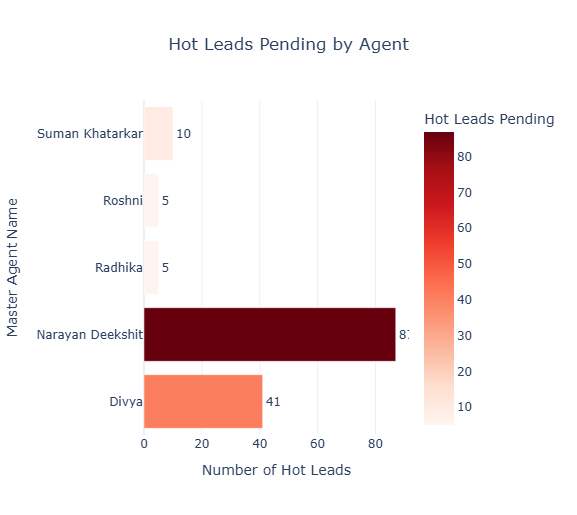

In [ ]:
import pandas as pd
import plotly.express as px


sheet_id = input("Enter Google Sheet ID: ")
sheet_name = input("Enter Sheet Name: ")
gid = input("Enter GID")
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(url)


df["Follow Up Date"] = pd.to_datetime(df["Follow Up Date"], dayfirst=True)

df["Disposition"] = (
    df["Disposition"]
    .astype(str)
    .str.strip()
    .str.lower()
)


today = pd.Timestamp.today().normalize()



hot_leads = df[
    (df["Disposition"] == "interested") &
    (df["Follow Up Date"] >= today)
]


hot_leads_agent = (
    hot_leads.groupby("Master Agent Name")
    .size()
    .reset_index(name="Hot Leads Pending")
)



fig = px.bar(
    hot_leads_agent,
    x="Hot Leads Pending",
    y="Master Agent Name",
    orientation="h",
    color="Hot Leads Pending",
    color_continuous_scale="Reds",
    text="Hot Leads Pending",
    title="Hot Leads Pending by Agent"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    height=500,
    width=900,
    title_x=0.5,
    xaxis_title="Number of Hot Leads",
    yaxis_title="Master Agent Name"
)

fig.show()